# Week 4 - Lab

## 1) Setup / Import

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
df = pd.read_csv("music_streams.csv")

In [3]:
import sys
print(sys.executable)

/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/bin/python


In [4]:
import sys
!{sys.executable} -m pip install altair

## 2) Explore

In [5]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [6]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [7]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


### Histogram

#### Monthly Streams

In [8]:
def create_histogram(column_name, title, x_label, y_label, filter_data=None):
    _df = df
    if filter_data:
        _df = df[df[column_name] > 1990 ]
    
    # Resize & Re-Colour
    fig, ax = plt.subplots(figsize=(9, 4))
    
    # Calculations
    median = df[column_name].median()
    mean = df[column_name].mean()
    
    # Plot Settings
    sns.histplot(data=df[ df[column_name] < 100], x=column_name, bins=20, ax=ax)
    ax.axvline(median, color="darkorange", linestyle="--", label="median")
    ax.axvline(mean, color="darkred", label="mean")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(frameon=False)
    ax.set_title(title)
    plt.show()

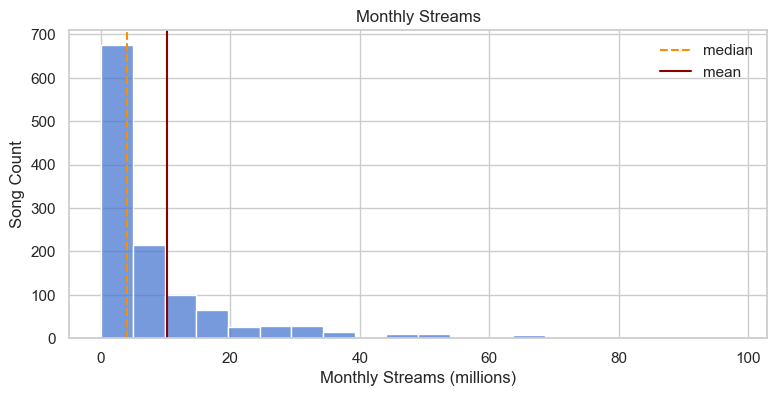

In [9]:
# Create chart
create_histogram("streams_millions", "Monthly Streams", "Monthly Streams (millions)", "Song Count")

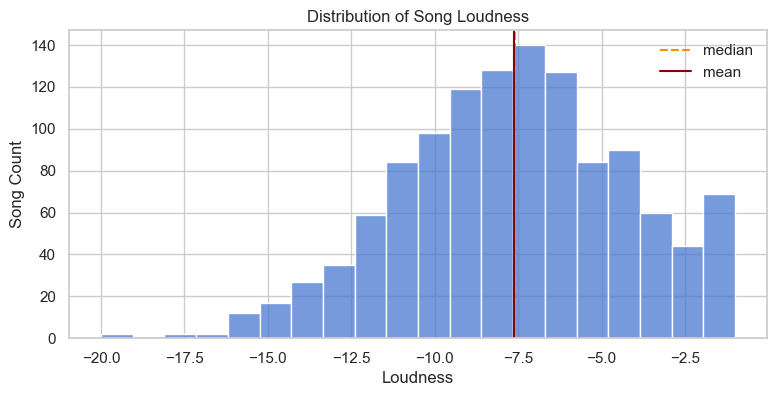

In [10]:
create_histogram("loudness_db", "Distribution of Song Loudness", "Loudness", "Song Count")

### Boxplot

In [11]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=True).index
order

Index(['R&B', 'Indie', 'Country', 'Pop', 'Hip-Hop', 'Latin', 'Rock',
       'Electronic'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

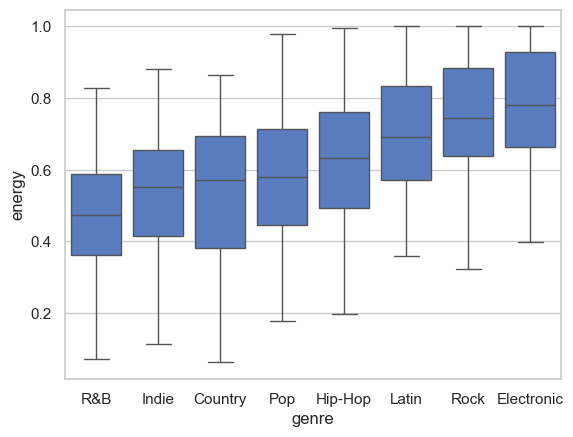

In [12]:
sns.boxplot(data=df, x="genre", y="energy", order=order)

In [13]:
order = df.groupby("year")
order

<Axes: xlabel='year', ylabel='danceability'>

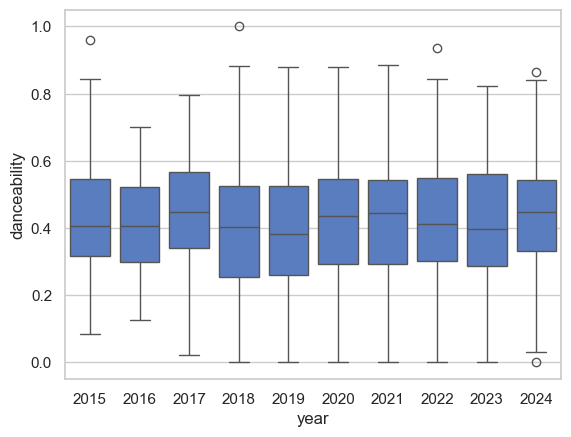

In [14]:
sns.boxplot(data=df, x="year", y="danceability")

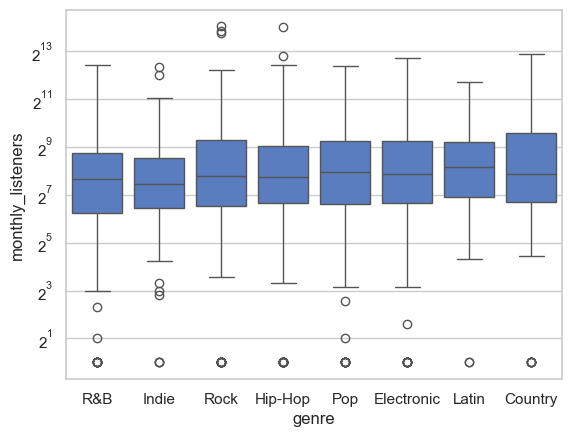

In [15]:
fig, ax = plt.subplots()
ax.set_yscale('log', base=2)
sns.boxplot(data=df, y="monthly_listeners", x="genre", ax=ax)
plt.show()

## Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

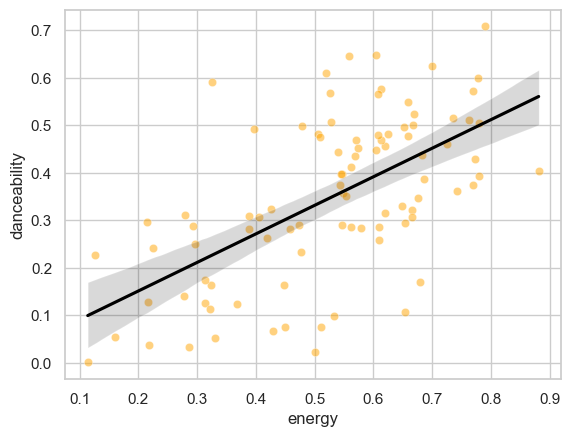

In [16]:
sample = df.sample(600)
sns.scatterplot(data=df [df["genre"] == "_data"] , x="energy", y="danceability", color="orange", alpha=0.5)
sns.regplot(data=df [df["genre"] == "_data"], x="energy", y="danceability", color="black", scatter=False,)

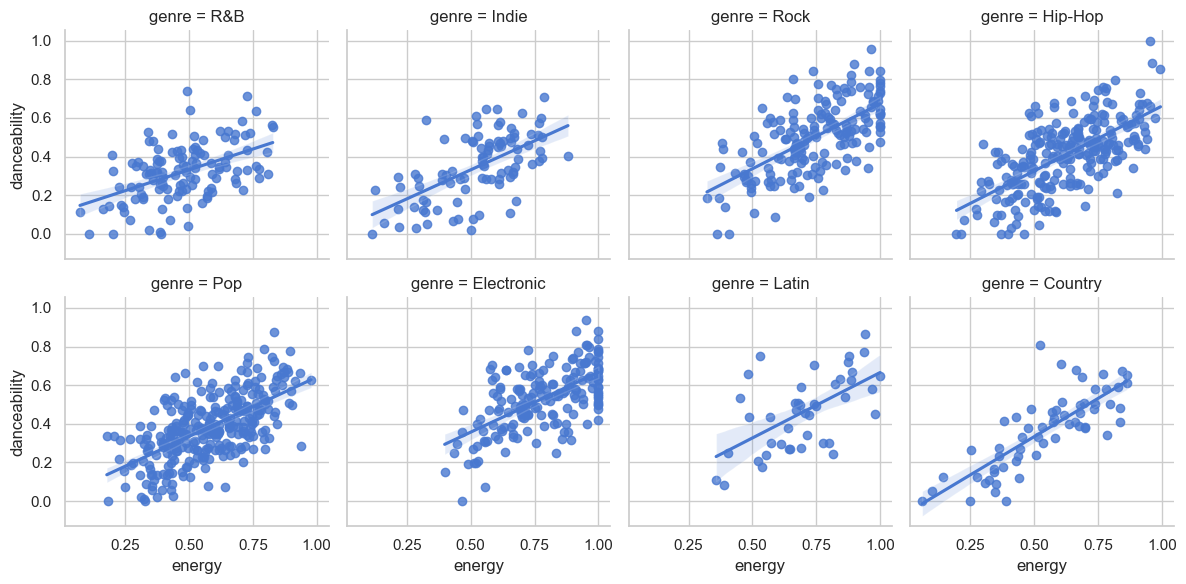

In [17]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.regplot, "energy", "danceability")

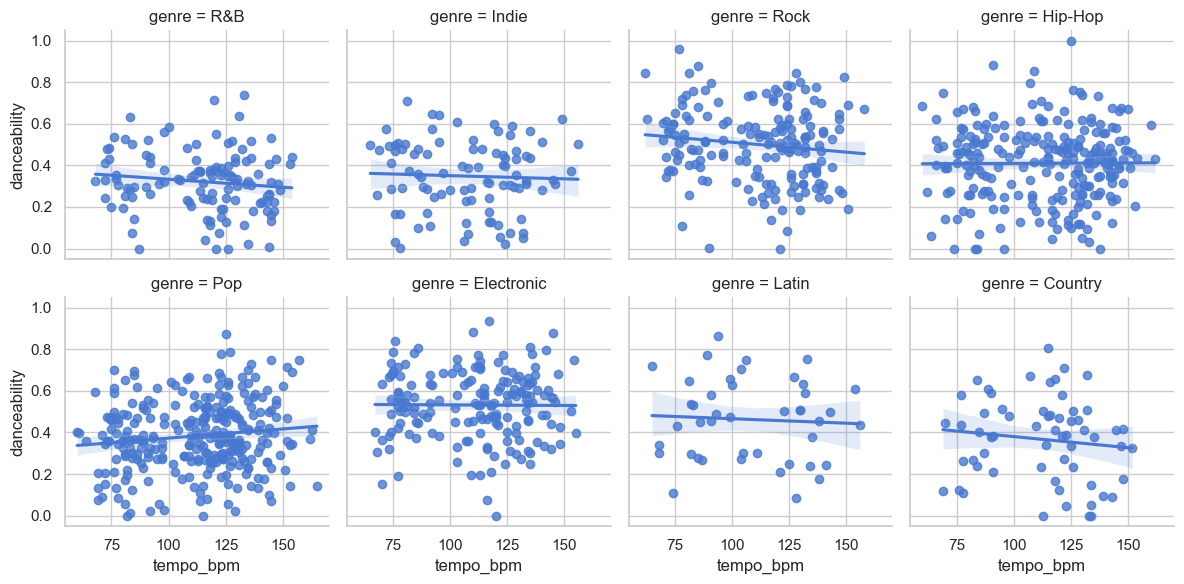

In [18]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.regplot, "tempo_bpm", "danceability")

In [19]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [20]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()

In [21]:
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

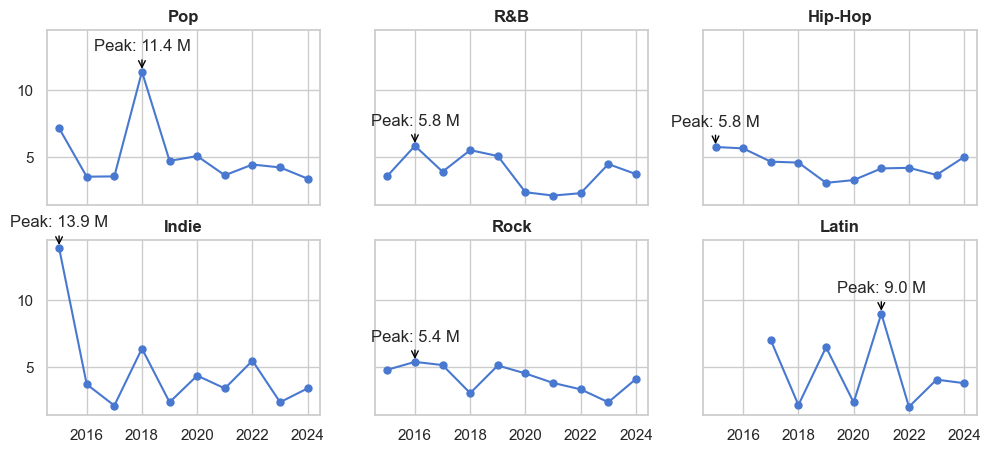

In [22]:
genres = set(list(df.genre.values))

trend= df[ df["genre"].isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2,3, figsize=(12, 5), sharex=True, sharey=True)
axes=axes.flatten()

for ax, genre in zip(axes, genres):
    sub = trend[trend.genre == genre]
    ax.plot(sub.year, sub.streams_millions, marker="o", ms=5)
    ax.set_title(genre, fontweight="bold")
    peak = sub.loc[sub.streams_millions.idxmax()]
    ax.annotate(
        f"Peak: {peak.streams_millions:.1f} M",
        xy=(peak.year, peak.streams_millions),
        xytext=(0, 15),
        textcoords="offset points",
        ha="center",
        arrowprops=dict(arrowstyle="->", color="black")
    )
    

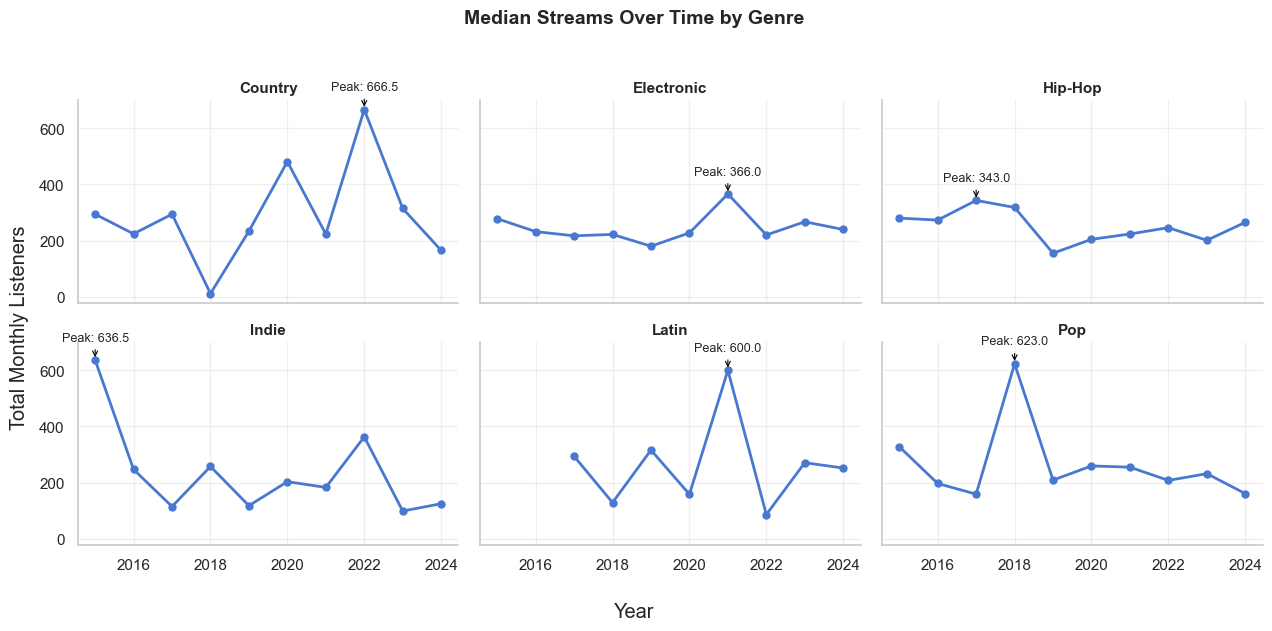

In [23]:
# Get genres in a consistent order
genres = sorted(df["genre"].dropna().unique())

y_val = "monthly_listeners"

trend = (
    df[df["genre"].isin(genres)]
    .groupby(["year", "genre"])[y_val]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    sub = trend[trend["genre"] == genre].sort_values("year")

    ax.plot(
        sub["year"],
        sub[y_val],
        marker="o",
        markersize=5,
        linewidth=2
    )

    ax.set_title(genre, fontweight="bold", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Annotate peak
    peak = sub.loc[sub[y_val].idxmax()]

    ax.annotate(
        f"Peak: {peak[y_val]}",
        xy=(peak.year, peak[y_val]),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8
        )
    )

# Hide unused subplots if there are fewer than 6 genres
for ax in axes[len(genres):]:
    ax.set_visible(False)

fig.suptitle(
    "Median Streams Over Time by Genre",
    fontsize=14,
    fontweight="bold",
    y=1.03
)

fig.supxlabel("Year")
fig.supylabel("Total Monthly Listeners")

plt.tight_layout()
plt.show()

In [30]:
import altair as alt

# Code adapted from here: https://altair-viz.github.io/gallery/interactive_aggregation.html

_data = df

slider = alt.binding_range(min=0, max=1, step=0.05)
threshold = alt.param(name="threshold", value=0, bind=slider)

# Plot individual
individual_points = alt.Chart(_data).mark_circle(
    color="orange",
    opacity=0.5,
    size=60
).encode(
    x=alt.X("energy:Q").title("Energy"),
    y=alt.Y("danceability:Q").title("Danceability")
).transform_filter(
    alt.datum.energy >= threshold
)


# Aggregate
aggregated_points = alt.Chart(_data).mark_circle(
    color="orange",
    opacity=0.65
).encode(
    x=alt.X("energy:Q", bin=alt.Bin(maxbins=10)).title("Energy"),
    y=alt.Y("danceability:Q", bin=alt.Bin(maxbins=10)).title("Danceability"),
    size=alt.Size("count():Q").title("Number of Songs")
).transform_filter(
    alt.datum.energy < threshold
)

# Get regression line
regression = alt.Chart(_data).transform_regression(
    "energy",
    "danceability"
).mark_line(
    color="black"
).encode(
    x=alt.X("energy:Q").title("Energy"),
    y=alt.Y("danceability:Q").title("Danceability")
)

# Threshold
threshold_rule = alt.Chart().mark_rule(
    color="gray",
    strokeWidth=4
).encode(
    x=alt.X(datum=alt.expr(threshold.name), type="quantitative")
)

# The chart
chart = alt.layer(
    individual_points,
    aggregated_points,
    regression,
    threshold_rule
).add_params(
    threshold
).properties(
    width=550,
    height=375,
    title="Energy vs Danceability for _data Songs"
)

chart

alt.LayerChart(...)